# Tasks 4.4, 4.5, 4.6, and 4.10

## Task 4.4
**4.4 Predict magnitude of antibody response - all 3 vaccine strains (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geo mean of HAI across the 3 vaccine strains (4.1, 4.2, 4.3) at Day 28

> **Note — missing strain:** `H3N2 A/Massachusetts/18/2022` has no training measurements (challenge-only strain). This task effectively averages over the 2 vaccine strains that are present in `hai_cleaned.csv` (H1N1 A/Victoria/4897/2022 and Vic B/Austria/1359417/2021), not all 3.

## Task 4.5
**4.5 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geomean HAI across all variants at Day 28

## Task 4.6
**4.6 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Percentage / Metric: Spearman correlation
* Full description: Percentage of variants with HAI >= 40 at Day 28

## Task 4.10
**4.10 Predict antibody durability - all 3 vaccine strains (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate + **Day 28**
* Assay: HAI / Measure: Geo mean HAI / Metric: Spearman correlation
* Full description: Geo mean of HAI across the 3 vaccine strains at Day 365

> **Note — missing strain:** of the 3 vaccine strains, only `Vic B/Austria/1359417/2021` has a `_d365` column in the training data (H1N1 A/Victoria/4897/2022 stops at d28; H3N2 A/Massachusetts/18/2022 is absent entirely). This task therefore collapses to predicting Vic B D365 — effectively the same target as Task 4.9.

---

## Design notes

**y-values:** log2-transformed. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Metrics (RMSE, MAE, Spearman) are all in log2 space; CSVs use `np.exp2` to output raw titer scale values (task 4.6 outputs a percentage directly).

**Geo mean on log2 data:** HAI values in `hai_cleaned.csv` are already log2-transformed, so the arithmetic mean across strain columns equals log2(geometric mean) on the raw titer scale.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
VACCINE_STRAINS = [
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Austria/1359417/2021',
]
HAI_THRESHOLD = 40  # task 4.6: count variants with raw HAI >= 40

In [2]:
import numpy as np
import pandas as pd

from model_utils import evaluate, vaccine_cols

In [3]:
DATA_PATH = 'cleaned_data'
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

# Data is pre-cleaned: one row per participant, HAI columns as HAI_{strain}_d{timepoint},
# participant columns as PART_{field}.
data = train_hai.merge(train_participants, on='participant_id', how='inner')
part_cols = [c for c in data.columns if c.startswith('PART_')]
print(f'Merged shape: {data.shape}')

Merged shape: (3757, 201)


---

## Task 4.4 — Geo mean HAI across the 3 vaccine strains (D28)

Samples: 920   Features: 5
Spearman (5-fold CV): 0.628  (p-value: 3.896e-102)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.5787     2.4924   1.2019     0.6281


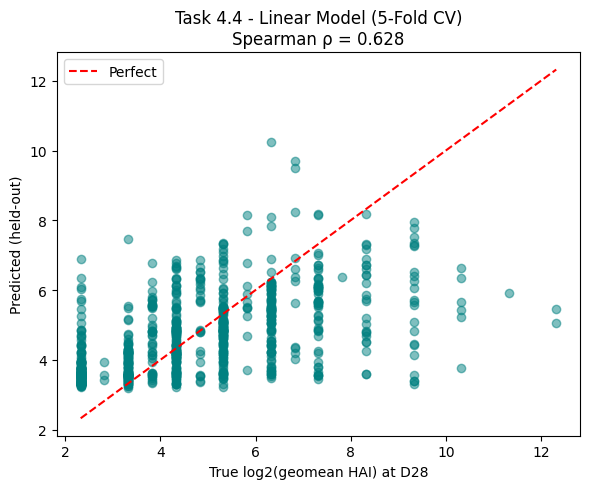

In [4]:
vaccine_d28_cols = vaccine_cols(data, VACCINE_STRAINS, '28')
vaccine_d0_cols = vaccine_cols(data, VACCINE_STRAINS, '0')

# Target: mean of log2 HAI at D28 across the 3 vaccine strains == log2(geomean on raw scale).
# Require at least one of the 3 strains to be measured; mean skips NaN.
y_vals = data[vaccine_d28_cols].mean(axis=1, skipna=True)
mask = y_vals.notna()
y_vals = y_vals[mask]

feature_cols = vaccine_d0_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, _ = evaluate(X, y_vals, 'Task 4.4', y_axis_label='True log2(geomean HAI) at D28')

In [5]:
results = pd.DataFrame({
    'Participant_ID': data.loc[mask, 'participant_id'].values,
    'Task_4.4*': np.exp2(y_pred_cv),  # reverse log2 -> raw titer geomean
})
results.to_csv('submission/task_4_4.csv', index=False)
results

,Participant_ID,Task_4.4*
0,2020_UGA.ID_001,11.948724
1,2020_UGA.ID_005,11.139879
2,2020_UGA.ID_008,11.927864
3,2020_UGA.ID_011,11.889159
4,2020_UGA.ID_014,13.653133
...,...,...
915,2023_UGA.ID_750,11.105875
916,2023_UGA.ID_751,10.363025
917,2023_UGA.ID_753,33.470994
918,2023_UGA.ID_754,28.009313


---

## Task 4.5 — Geo mean HAI across all variants (D28)

Samples: 3627   Features: 84
Spearman (5-fold CV): 0.744  (p-value: 0)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.0608     1.1252   0.7869     0.7437


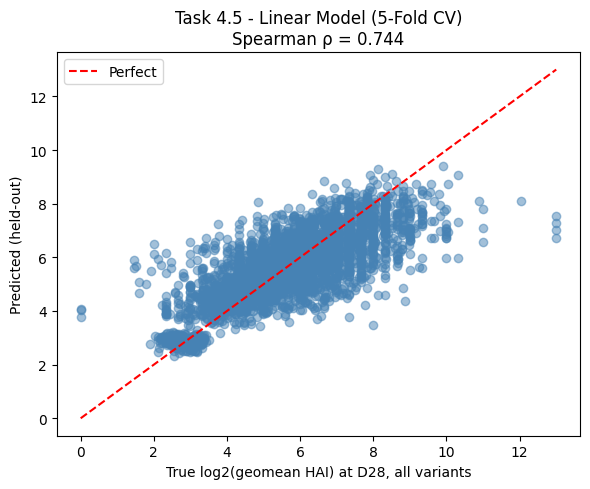

In [6]:
all_d28_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d28')]
all_d0_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d0')]

# Target: mean of log2 HAI at D28 across every measured strain.
y_vals = data[all_d28_cols].mean(axis=1, skipna=True)
mask = y_vals.notna()
y_vals = y_vals[mask]

feature_cols = all_d0_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, _ = evaluate(X, y_vals, 'Task 4.5', plot_color='steelblue',
                        y_axis_label='True log2(geomean HAI) at D28, all variants')

In [7]:
results = pd.DataFrame({
    'Participant_ID': data.loc[mask, 'participant_id'].values,
    'Task_4.5*': np.exp2(y_pred_cv),
})
results.to_csv('submission/task_4_5.csv', index=False)
results

,Participant_ID,Task_4.5*
0,2016_UGA.ID_001,111.052051
1,2016_UGA.ID_002,114.021216
2,2016_UGA.ID_003,67.712790
3,2016_UGA.ID_004,50.420341
4,2016_UGA.ID_005,58.961596
...,...,...
3622,SDY887.SUB134259,46.131922
3623,SDY887.SUB134260,53.075671
3624,SDY887.SUB197783,19.585965
3625,SDY887.SUB197784,41.711137


---

## Task 4.6 — Percentage of variants with HAI >= 40 (D28)

Samples: 3627   Features: 84
Spearman (5-fold CV): 0.696  (p-value: 0)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              0.2208     0.0488   0.1672     0.6957


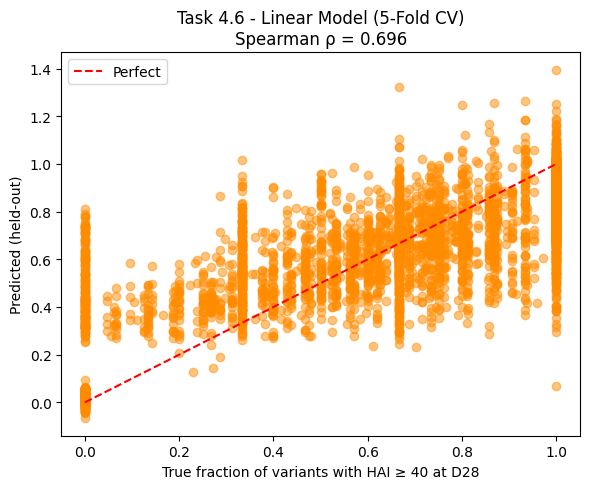

In [8]:
# HAI values in the cleaned table are log2. Compare against log2(40) ~ 5.32.
threshold_log2 = np.log2(HAI_THRESHOLD)

d28_block = data[all_d28_cols]
# For each participant: fraction of measured variants meeting the threshold.
# Use the boolean sum / non-null count so unmeasured strains don't skew the ratio.
above = (d28_block >= threshold_log2).sum(axis=1)
measured = d28_block.notna().sum(axis=1)
y_vals = (above / measured).where(measured > 0)

mask = y_vals.notna()
y_vals = y_vals[mask]

feature_cols = all_d0_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, _ = evaluate(X, y_vals, 'Task 4.6', plot_color='darkorange',
                        y_axis_label='True fraction of variants with HAI \u2265 40 at D28')

In [9]:
results = pd.DataFrame({
    'Participant_ID': data.loc[mask, 'participant_id'].values,
    'Task_4.6': y_pred_cv,  # already a fraction - no inverse transform
})
results.to_csv('submission/task_4_6.csv', index=False)
results

,Participant_ID,Task_4.6
0,2016_UGA.ID_001,0.825830
1,2016_UGA.ID_002,0.802030
2,2016_UGA.ID_003,0.674154
3,2016_UGA.ID_004,0.589003
4,2016_UGA.ID_005,0.587596
...,...,...
3622,SDY887.SUB134259,0.537738
3623,SDY887.SUB134260,0.521246
3624,SDY887.SUB197783,0.286129
3625,SDY887.SUB197784,0.548640


---

## Task 4.10 — Geo mean HAI across the 3 vaccine strains (D365)

Samples: 492   Features: 7
Spearman (5-fold CV): 0.755  (p-value: 6.383e-92)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.0499     1.1023   0.7886     0.7552


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['HAI_H1N1 A/Victoria/4897/2022_d0' 'HAI_H1N1 A/Victoria/4897/2022_d28']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['HAI_H1N1 A/Victoria/4897/2022_d0' 'HAI_H1N1 A/Victoria/4897/2022_d28']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['HAI_H1N1 A/Victoria/4897/2022_d0' 'HAI_H1N1 A/Victoria/4897/2022_d28']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c

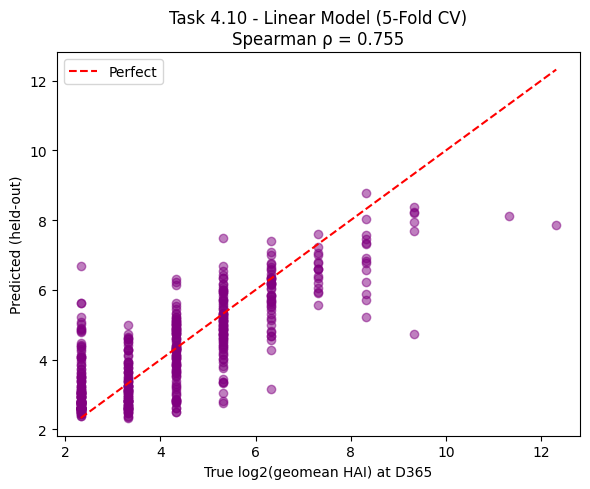

c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['HAI_H1N1 A/Victoria/4897/2022_d0' 'HAI_H1N1 A/Victoria/4897/2022_d28']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [10]:
vaccine_d365_cols = vaccine_cols(data, VACCINE_STRAINS, '365')

# Target: mean of log2 HAI at D365 across the 3 vaccine strains.
y_vals = data[vaccine_d365_cols].mean(axis=1, skipna=True)
mask = y_vals.notna()
y_vals = y_vals[mask]

# Features: d0 + d28 for the 3 vaccine strains + demographics (d28 is allowed for durability task).
feature_cols = vaccine_d0_cols + vaccine_d28_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, _ = evaluate(X, y_vals, 'Task 4.10', plot_color='purple',
                        y_axis_label='True log2(geomean HAI) at D365')

In [11]:
results = pd.DataFrame({
    'Participant_ID': data.loc[mask, 'participant_id'].values,
    'Task_4.10': np.exp2(y_pred_cv),
})
results.to_csv('submission/task_4_10.csv', index=False)
results

,Participant_ID,Task_4.10
0,2020_UGA.ID_001,6.102960
1,2020_UGA.ID_005,5.643303
2,2020_UGA.ID_008,6.130612
3,2020_UGA.ID_011,5.237966
4,2020_UGA.ID_014,6.840501
...,...,...
487,2022_UGA.ID_652,8.978648
488,2022_UGA.ID_653,47.878892
489,2022_UGA.ID_654,26.761492
490,2022_UGA.ID_717,49.697140
